This notebook covers the four pipeline tasks:
1. EDA on `discharge.csv`
2. Section-based chunking script
3. Save chunks to `chunks.parquet`
4. Join validation with `admissions.csv`

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from collections import Counter

# Adjust display settings
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_columns", 20)

---
## Task 1 — EDA on `discharge.csv`
Check row count, text length distribution, null values, and section headers.

In [2]:
# ── Load the data ──────────────────────────────────────────────
# Update the path to wherever your discharge.csv lives
DISCHARGE_PATH = "C:/Users/edana/Downloads/discharge.csv"

df_discharge = pd.read_csv(DISCHARGE_PATH)
print(f"Total rows : {len(df_discharge):,}")
print(f"Columns    : {list(df_discharge.columns)}")
df_discharge.head(3)

Total rows : 331,794
Columns    : ['note_id', 'subject_id', 'hadm_id', 'note_type', 'note_seq', 'charttime', 'storetime', 'text']


,note_id,subject_id,hadm_id,note_type,note_seq,charttime,storetime,text
0,10000032-DS-21,10000032,22595853,DS,21,2180-05-07 00:00:00,2180-05-09 15:26:00,\nName: ___ Unit No: ___\n \nAdmission Date: ___ Discharge Date: ___\n \nDat...
1,10000032-DS-22,10000032,22841357,DS,22,2180-06-27 00:00:00,2180-07-01 10:15:00,\nName: ___ Unit No: ___\n \nAdmission Date: ___ Discharge Date: ___\n \nDat...
2,10000032-DS-23,10000032,29079034,DS,23,2180-07-25 00:00:00,2180-07-25 21:42:00,\nName: ___ Unit No: ___\n \nAdmission Date: ___ Discharge Date: ___\n \nDat...


In [3]:
# ── Null value report ──────────────────────────────────────────
null_report = pd.DataFrame({
    "null_count": df_discharge.isnull().sum(),
    "null_pct": (df_discharge.isnull().sum() / len(df_discharge) * 100).round(2),
    "dtype": df_discharge.dtypes
})
print("── Null values per column ──")
null_report

── Null values per column ──


,null_count,null_pct,dtype
note_id,0,0.00,object
subject_id,0,0.00,int64
hadm_id,0,0.00,int64
note_type,0,0.00,object
note_seq,0,0.00,int64
charttime,0,0.00,object
storetime,17,0.01,object
text,0,0.00,object


── Text length statistics (characters) ──
count    331794.000000
mean      10550.969767
std        4452.120954
min         353.000000
25%        7462.000000
50%        9847.000000
75%       12831.000000
max       60381.000000


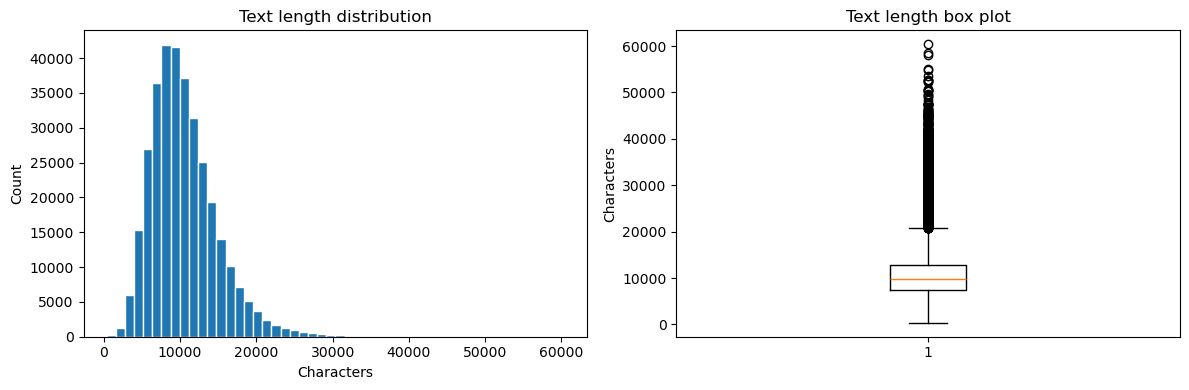

In [4]:
# ── Text length distribution ───────────────────────────────────
# Adjust 'text' to whatever column holds the discharge note body
TEXT_COL = "text"

df_discharge["text_len"] = df_discharge[TEXT_COL].fillna("").str.len()

print("── Text length statistics (characters) ──")
print(df_discharge["text_len"].describe().to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_discharge["text_len"], bins=50, edgecolor="white")
axes[0].set_title("Text length distribution")
axes[0].set_xlabel("Characters")
axes[0].set_ylabel("Count")

axes[1].boxplot(df_discharge["text_len"], vert=True)
axes[1].set_title("Text length box plot")
axes[1].set_ylabel("Characters")
plt.tight_layout()
plt.show()

In [5]:
# ── Discover section headers ───────────────────────────────────
# Looks for patterns like "Section Name:" at the start of a line
SECTION_PATTERN = re.compile(r"^([A-Z][A-Za-z\s/&\-]{2,50}):" , re.MULTILINE)

all_sections = []
for text in df_discharge[TEXT_COL].dropna():
    all_sections.extend(SECTION_PATTERN.findall(text))

section_counts = Counter(s.strip() for s in all_sections)

print(f"Unique section headers found: {len(section_counts)}")
print("\n── Top 30 most common sections ──")
for section, count in section_counts.most_common(30):
    pct = count / len(df_discharge) * 100
    print(f"  {section:40s}  {count:>6,}  ({pct:5.1f}%)")

Unique section headers found: 346007

── Top 30 most common sections ──
  Past Medical History                      334,041  (100.7%)
  Name                                      333,399  (100.5%)
  Allergies                                 333,373  (100.5%)
  Date of Birth                             331,978  (100.1%)
  Admission Date                            331,781  (100.0%)
  Service                                   331,752  (100.0%)
  Family History                            324,260  ( 97.7%)
  Chief Complaint                           321,433  ( 96.9%)
  Discharge Disposition                     317,968  ( 95.8%)
  Followup Instructions                     317,119  ( 95.6%)
  Medications on Admission                  310,151  ( 93.5%)
  Discharge Instructions                    308,240  ( 92.9%)
  Pertinent Results                         305,487  ( 92.1%)
  Discharge Medications                     297,180  ( 89.6%)
  HEENT                                     291,996  ( 88.0%

In [6]:
# ── Peek at a sample note to eyeball the section structure ─────
sample_note = df_discharge[TEXT_COL].dropna().iloc[0]
print(sample_note[:2000])

 
Name:  ___                     Unit No:   ___
 
Admission Date:  ___              Discharge Date:   ___
 
Date of Birth:  ___             Sex:   F
 
Service: MEDICINE
 
Allergies: 
No Known Allergies / Adverse Drug Reactions
 
Attending: ___
 
Chief Complaint:
Worsening ABD distension and pain 
 
Major Surgical or Invasive Procedure:
Paracentesis

 
History of Present Illness:
___ HCV cirrhosis c/b ascites, hiv on ART, h/o IVDU, COPD, 
bioplar, PTSD, presented from OSH ED with worsening abd 
distension over past week.  
Pt reports self-discontinuing lasix and spirnolactone ___ weeks 
ago, because she feels like "they don't do anything" and that 
she "doesn't want to put more chemicals in her." She does not 
follow Na-restricted diets. In the past week, she notes that she 
has been having worsening abd distension and discomfort. She 
denies ___ edema, or SOB, or orthopnea. She denies f/c/n/v, d/c, 
dysuria. She had food poisoning a week ago from eating stale 
cake (n/v 20 min after fo

---
## Task 2 — Section-based Chunking Script
Split each note by its section headers, keeping `note_id`, `subject_id`, `hadm_id` as metadata.

In [7]:
def chunk_note_by_section(text: str, section_pattern: re.Pattern = SECTION_PATTERN) -> list[dict]:
    """
    Split a discharge note into chunks, one per section.

    Returns a list of dicts with keys:
        - section_name : str   (e.g. "Chief Complaint")
        - section_text : str   (the body text under that header)
    
    Text before the first recognized header is returned under
    section_name = "Preamble".
    """
    if not isinstance(text, str) or not text.strip():
        return []

    # Find all header positions
    matches = list(section_pattern.finditer(text))

    chunks = []

    # Capture any text before the first header
    if matches and matches[0].start() > 0:
        preamble = text[: matches[0].start()].strip()
        if preamble:
            chunks.append({"section_name": "Preamble", "section_text": preamble})

    for i, match in enumerate(matches):
        section_name = match.group(1).strip()
        start = match.end()                            # right after the colon
        end = matches[i + 1].start() if i + 1 < len(matches) else len(text)
        body = text[start:end].strip()
        if body:
            chunks.append({"section_name": section_name, "section_text": body})

    # Fallback: if no sections detected, return the whole note as one chunk
    if not chunks:
        chunks.append({"section_name": "Full Note", "section_text": text.strip()})

    return chunks

In [8]:
# ── Apply chunking to every note ──────────────────────────────
# Adjust these column names if yours differ
ID_COLS = ["note_id", "subject_id", "hadm_id"]

rows = []
for _, row in df_discharge.iterrows():
    chunks = chunk_note_by_section(row.get(TEXT_COL, ""))
    for idx, chunk in enumerate(chunks):
        rows.append({
            **{col: row.get(col) for col in ID_COLS},
            "chunk_index": idx,
            "section_name": chunk["section_name"],
            "section_text": chunk["section_text"],
            "chunk_char_len": len(chunk["section_text"]),
        })

df_chunks = pd.DataFrame(rows)

print(f"Total chunks created : {len(df_chunks):,}")
print(f"From {df_chunks['note_id'].nunique():,} unique notes")
print(f"\nChunk length stats (chars):")
print(df_chunks["chunk_char_len"].describe().to_string())
df_chunks.head(10)

Total chunks created : 12,826,589
From 331,794 unique notes

Chunk length stats (chars):
count    1.282659e+07
mean     2.508021e+02
std      5.615282e+02
min      1.000000e+00
25%      2.200000e+01
50%      4.700000e+01
75%      2.010000e+02
max      2.935700e+04


,note_id,subject_id,hadm_id,chunk_index,section_name,section_text,chunk_char_len
0,10000032-DS-21,10000032,22595853,0,Name,___ Unit No: ___,38
1,10000032-DS-21,10000032,22595853,1,Admission Date,___ Discharge Date: ___,38
2,10000032-DS-21,10000032,22595853,2,Date of Birth,___ Sex: F,24
3,10000032-DS-21,10000032,22595853,3,Service,MEDICINE,8
4,10000032-DS-21,10000032,22595853,4,Allergies,No Known Allergies / Adverse Drug Reactions,43
5,10000032-DS-21,10000032,22595853,5,Attending,___,3
6,10000032-DS-21,10000032,22595853,6,Chief Complaint,Worsening ABD distension and pain,33
7,10000032-DS-21,10000032,22595853,7,Paracentesis\n\n \nHistory of Present Illness,"___ HCV cirrhosis c/b ascites, hiv on ART, h/o IVDU, COPD, \nbioplar, PTSD, presented from OSH ED with worsening abd...",1342
8,10000032-DS-21,10000032,22595853,8,Past Medical History,"1. HCV Cirrhosis \n2. No history of abnormal Pap smears. \n3. She had calcification in her breast, which was remov...",858
9,10000032-DS-21,10000032,22595853,9,Social History,___,3


In [9]:
# ── Section distribution across chunks ────────────────────────
print("── Chunks per section name (top 20) ──")
print(df_chunks["section_name"].value_counts().head(20).to_string())

── Chunks per section name (top 20) ──
section_name
Name                        333398
Date of Birth               331977
Admission Date              331781
Service                     331643
Followup Instructions       317119
Discharge Medications       292891
Discharge Instructions      292884
HEENT                       291636
Medications on Admission    291057
Chief Complaint             269930
Brief Hospital Course       259144
Mental Status               257405
Disp                        257073
Level of Consciousness      253006
Social History              252593
Activity Status             252420
Past Medical History        252352
Family History              249963
Allergies                   244049
Attending                   230830


---
## Task 3 — Save to `chunks.parquet`
Write the chunked dataframe to Parquet (then upload to the shared S3 bucket).

In [10]:
PARQUET_PATH = "chunks.parquet"

df_chunks.to_parquet(PARQUET_PATH, index=False, engine="pyarrow")

# Quick sanity check: re-read and verify
df_verify = pd.read_parquet(PARQUET_PATH)
assert len(df_verify) == len(df_chunks), "Row count mismatch!"
print(f"Saved {len(df_verify):,} chunks to {PARQUET_PATH}")
print(f"File size: {pd.io.common.file_exists(PARQUET_PATH) and round(__import__('os').path.getsize(PARQUET_PATH) / 1e6, 2)} MB")

Saved 12,826,589 chunks to chunks.parquet
File size: 1856.48 MB


In [ ]:
# ── Upload to S3 (uncomment and set your bucket/path) ─────────
# import boto3
# 
# S3_BUCKET = "your-shared-bucket"
# S3_KEY    = "rag-project/data/chunks.parquet"
# 
# s3 = boto3.client("s3")
# s3.upload_file(PARQUET_PATH, S3_BUCKET, S3_KEY)
# print(f"Uploaded to s3://{S3_BUCKET}/{S3_KEY}")

---
## Task 4 — Join Validation: `discharge.csv` ↔ `admissions.csv`
Confirm the join on `hadm_id` and document coverage.

In [11]:
# ── Load admissions ───────────────────────────────────────────
ADMISSIONS_PATH = "C:/Users/edana/Downloads/admissions.csv"

df_admissions = pd.read_csv(ADMISSIONS_PATH)
print(f"Admissions rows    : {len(df_admissions):,}")
print(f"Unique hadm_id     : {df_admissions['hadm_id'].nunique():,}")
df_admissions.head(3)

Admissions rows    : 546,028
Unique hadm_id     : 546,028


,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0
1,10000032,22841357,2180-06-26 18:27:00,2180-06-27 18:49:00,NaN,EW EMER.,P784FA,EMERGENCY ROOM,HOME,Medicaid,English,WIDOWED,WHITE,2180-06-26 15:54:00,2180-06-26 21:31:00,0
2,10000032,25742920,2180-08-05 23:44:00,2180-08-07 17:50:00,NaN,EW EMER.,P19UTS,EMERGENCY ROOM,HOSPICE,Medicaid,English,WIDOWED,WHITE,2180-08-05 20:58:00,2180-08-06 01:44:00,0


In [12]:
# ── Join analysis ─────────────────────────────────────────────
discharge_ids  = set(df_discharge["hadm_id"].dropna().unique())
admission_ids  = set(df_admissions["hadm_id"].dropna().unique())

matched       = discharge_ids & admission_ids
discharge_only = discharge_ids - admission_ids
admission_only = admission_ids - discharge_ids

print("── hadm_id Join Summary ──")
print(f"Discharge notes total        : {len(discharge_ids):,}")
print(f"Admissions records total     : {len(admission_ids):,}")
print(f"Successfully linked (inner)  : {len(matched):,}  "
      f"({len(matched)/len(discharge_ids)*100:.1f}% of discharge notes)")
print(f"In discharge only (no match) : {len(discharge_only):,}")
print(f"In admissions only (no note) : {len(admission_only):,}")

── hadm_id Join Summary ──
Discharge notes total        : 331,794
Admissions records total     : 546,028
Successfully linked (inner)  : 331,732  (100.0% of discharge notes)
In discharge only (no match) : 62
In admissions only (no note) : 214,296


In [13]:
# ── Perform the actual join & preview ─────────────────────────
df_joined = df_discharge.merge(df_admissions, on="hadm_id", how="inner", suffixes=("_note", "_adm"))

print(f"Joined dataframe rows: {len(df_joined):,}")
print(f"Columns: {list(df_joined.columns)}")
df_joined.head(3)

Joined dataframe rows: 331,732
Columns: ['note_id', 'subject_id_note', 'hadm_id', 'note_type', 'note_seq', 'charttime', 'storetime', 'text', 'text_len', 'subject_id_adm', 'admittime', 'dischtime', 'deathtime', 'admission_type', 'admit_provider_id', 'admission_location', 'discharge_location', 'insurance', 'language', 'marital_status', 'race', 'edregtime', 'edouttime', 'hospital_expire_flag']


,note_id,subject_id_note,hadm_id,note_type,note_seq,charttime,storetime,text,text_len,subject_id_adm,...,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag
0,10000032-DS-21,10000032,22595853,DS,21,2180-05-07 00:00:00,2180-05-09 15:26:00,\nName: ___ Unit No: ___\n \nAdmission Date: ___ Discharge Date: ___\n \nDat...,7530,10000032,...,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0
1,10000032-DS-22,10000032,22841357,DS,22,2180-06-27 00:00:00,2180-07-01 10:15:00,\nName: ___ Unit No: ___\n \nAdmission Date: ___ Discharge Date: ___\n \nDat...,10922,10000032,...,P784FA,EMERGENCY ROOM,HOME,Medicaid,English,WIDOWED,WHITE,2180-06-26 15:54:00,2180-06-26 21:31:00,0
2,10000032-DS-23,10000032,29079034,DS,23,2180-07-25 00:00:00,2180-07-25 21:42:00,\nName: ___ Unit No: ___\n \nAdmission Date: ___ Discharge Date: ___\n \nDat...,10608,10000032,...,P06OTX,EMERGENCY ROOM,HOME,Medicaid,English,WIDOWED,WHITE,2180-07-23 05:54:00,2180-07-23 14:00:00,0


In [14]:
# ── Quick summary table for documentation ─────────────────────
summary = pd.DataFrame([
    {"metric": "discharge.csv rows",               "value": len(df_discharge)},
    {"metric": "admissions.csv rows",              "value": len(df_admissions)},
    {"metric": "Unique hadm_id (discharge)",       "value": len(discharge_ids)},
    {"metric": "Unique hadm_id (admissions)",      "value": len(admission_ids)},
    {"metric": "Successfully linked (inner join)", "value": len(matched)},
    {"metric": "Link rate (% of discharge notes)", "value": f"{len(matched)/len(discharge_ids)*100:.1f}%"},
    {"metric": "Total chunks created",             "value": len(df_chunks)},
    {"metric": "Unique sections discovered",       "value": df_chunks['section_name'].nunique()},
])
print("\n══════ Pipeline Summary ══════")
print(summary.to_string(index=False))


══════ Pipeline Summary ══════
                          metric    value
              discharge.csv rows   331794
             admissions.csv rows   546028
      Unique hadm_id (discharge)   331794
     Unique hadm_id (admissions)   546028
Successfully linked (inner join)   331732
Link rate (% of discharge notes)   100.0%
            Total chunks created 12826589
      Unique sections discovered   279836
